In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/vendas.csv")
df["data"] = pd.to_datetime(df["data"])

## Insight

O faturamento entre os produtos apresentou uma distribuição relativamente equilibrada, sem um único produto concentrando grande parte das vendas. Como o conjunto de dados foi gerado de forma aleatória para fins de estudo, esse comportamento é esperado. Em um cenário real, essa análise ajudaria a identificar os produtos com maior potencial de receita e apoiar decisões de estoque e estratégias de vendas.

In [4]:
faturamento_estado = (
    df.groupby("estado")["faturamento"]
      .sum()
      .sort_values(ascending=False)
)

faturamento_estado

estado
MG    11079927.25
BA    11007744.05
PR    10887024.65
SP    10838208.89
RJ    10818003.08
SC    10798613.72
RS    10584716.55
Name: faturamento, dtype: float64

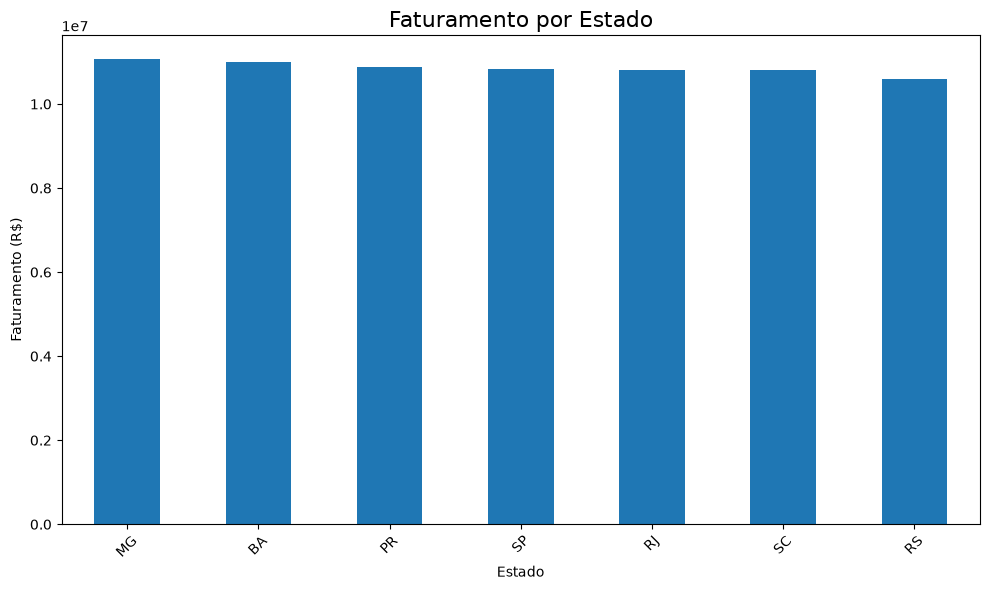

In [5]:
plt.figure(figsize=(10,6))

faturamento_estado.plot(kind="bar")

plt.title("Faturamento por Estado", fontsize=16)
plt.xlabel("Estado")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/faturamento_estado.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight

A análise do faturamento por estado permite identificar quais regiões geram maior receita para o e-commerce. Em um cenário real, essa informação poderia orientar decisões sobre campanhas de marketing, expansão logística e estratégias comerciais específicas para cada estado.

In [6]:
df["mes"] = df["data"].dt.to_period("M")
df.head()

,data,cliente_id,produto,categoria,estado,quantidade,preco,faturamento,mes
0,2024-08-11,3663,Mesa,Casa,RJ,1,4552.81,4552.81,2024-08
1,2025-07-14,1950,Fone,Eletrônicos,BA,2,3756.05,7512.10,2025-07
2,2025-06-08,3881,Mouse,Eletrônicos,SC,1,1218.68,1218.68,2025-06
3,2024-12-09,4021,Mesa,Casa,RS,4,2350.20,9400.80,2024-12
4,2025-12-15,4503,Cadeira,Casa,RS,4,764.00,3056.00,2025-12


In [7]:
faturamento_mes = (
    df.groupby("mes")["faturamento"]
      .sum()
)

faturamento_mes

mes
2023-01    2318755.55
2023-02    1777717.78
2023-03    2504824.07
2023-04    2071881.43
2023-05    2033401.47
2023-06    1902741.34
2023-07    2239733.22
2023-08    2270961.39
2023-09    2106118.47
2023-10    2069527.21
2023-11    2179387.59
2023-12    1974612.74
2024-01    1982443.55
2024-02    2232791.03
2024-03    2291641.71
2024-04    2190509.15
2024-05    2076208.08
2024-06    2172038.75
2024-07    2032406.49
2024-08    2104508.29
2024-09    1989219.86
2024-10    2025420.46
2024-11    2064234.66
2024-12    2017314.46
2025-01    2101070.40
2025-02    1947796.42
2025-03    2049310.62
2025-04    2082749.15
2025-05    2353745.00
2025-06    1892818.93
2025-07    1908355.93
2025-08    2107251.00
2025-09    2212977.11
2025-10    2349675.40
2025-11    2212586.57
2025-12    2167502.91
Freq: M, Name: faturamento, dtype: float64

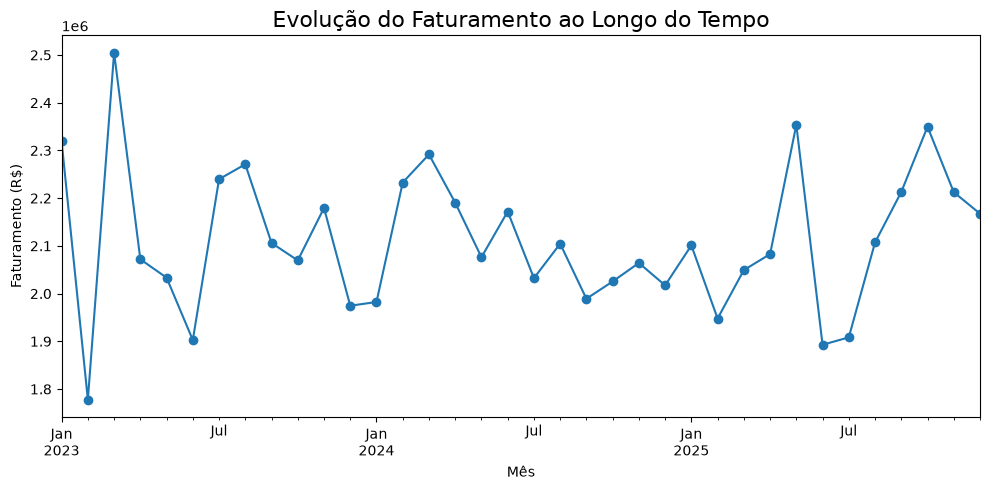

In [8]:
plt.figure(figsize=(10,5))

faturamento_mes.plot(kind="line", marker="o")

plt.title("Evolução do Faturamento ao Longo do Tempo", fontsize=16)
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")

plt.tight_layout()

plt.savefig("../images/faturamento_mensal.png", dpi=300, bbox_inches="tight")

plt.show()

In [9]:
faturamento_total = df["faturamento"].sum()

print(f"Faturamento Total: R$ {faturamento_total:,.2f}")

Faturamento Total: R$ 76,014,238.19


In [10]:
ticket_medio = df["faturamento"].mean()

print(f"Ticket Médio: R$ {ticket_medio:,.2f}")

Ticket Médio: R$ 7,601.42


In [11]:
quantidade_vendas = len(df)

print(f"Quantidade de vendas: {quantidade_vendas}")

Quantidade de vendas: 10000


In [12]:
produto_mais_vendido = (
    df.groupby("produto")["quantidade"]
      .sum()
      .sort_values(ascending=False)
)

produto_mais_vendido

produto
Mouse       3877
Notebook    3867
Mesa        3797
Teclado     3775
Celular     3730
Fone        3687
Cadeira     3663
Monitor     3605
Name: quantidade, dtype: int64

## Insight

O Mouse foi o produto com maior quantidade de unidades vendidas (3.877), seguido de perto pelo Notebook (3.867). Como o conjunto de dados é simulado, não há uma grande concentração de vendas em um único produto. Em um cenário real, essa análise ajudaria a identificar os produtos com maior demanda e apoiar decisões de estoque e compras.

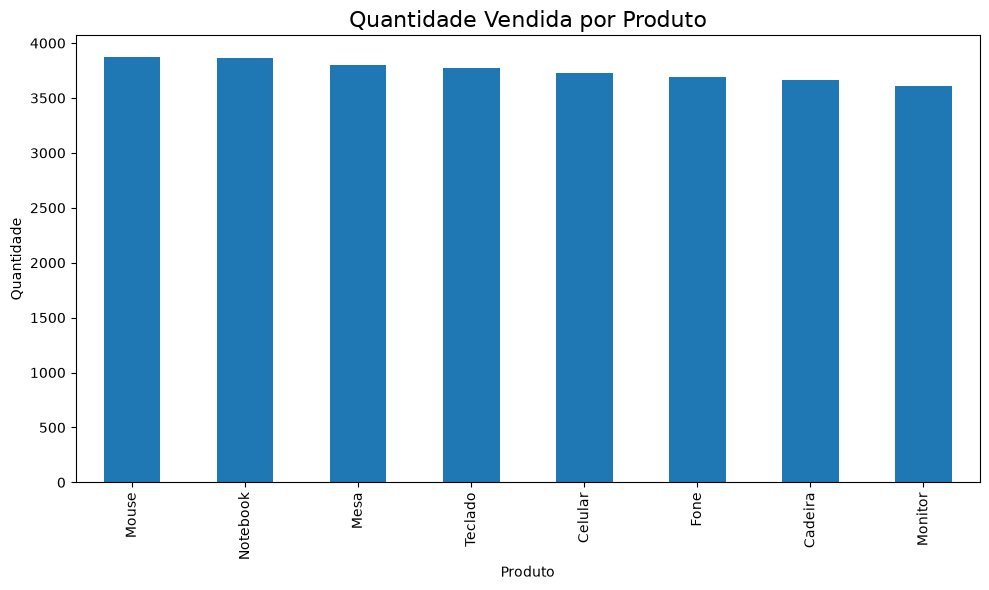

In [13]:
plt.figure(figsize=(10,6))

produto_mais_vendido.plot(kind="bar")

plt.title("Quantidade Vendida por Produto", fontsize=16)
plt.xlabel("Produto")
plt.ylabel("Quantidade")

plt.tight_layout()

plt.savefig("../images/quantidade_produto.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
faturamento_total = df["faturamento"].sum()
ticket_medio = df["faturamento"].mean()
quantidade_vendas = len(df)
clientes_unicos = df["cliente_id"].nunique()

print(f"💰 Faturamento Total : R$ {faturamento_total:,.2f}")
print(f"🛒 Ticket Médio      : R$ {ticket_medio:,.2f}")
print(f"📦 Total de Vendas   : {quantidade_vendas}")
print(f"👥 Clientes Únicos   : {clientes_unicos}")

💰 Faturamento Total : R$ 76,014,238.19
🛒 Ticket Médio      : R$ 7,601.42
📦 Total de Vendas   : 10000
👥 Clientes Únicos   : 3689
